In [1]:
import pandas as pd
import numpy as np

# Load datasets from data directory
customers = pd.read_csv('../data/customers.csv')
products = pd.read_csv('../data/products.csv')
sessions = pd.read_csv('../data/sessions.csv')
orders = pd.read_csv('../data/orders.csv')
order_items = pd.read_csv('../data/order_items.csv')

datasets = {
    'customers': customers,
    'products': products,
    'sessions': sessions,
    'orders': orders,
    'order_items': order_items
}

# General overview: shapes, duplicates, missing values
print("=== INITIAL DATA AUDIT REPORT ===\n")
for name, df in datasets.items():
    print(f"--- Dataset: {name} ---")
    print(f"Shape (Rows, Columns): {df.shape}")
    print(f"Full Duplicates: {df.duplicated().sum()}")
    print("Missing Values per Column:")
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(nulls[nulls > 0])
    else:
        print("  No missing values")
    print("-" * 40 + "\n")

=== INITIAL DATA AUDIT REPORT ===

--- Dataset: customers ---
Shape (Rows, Columns): (2005, 9)
Full Duplicates: 5
Missing Values per Column:
age     21
city    10
dtype: int64
----------------------------------------

--- Dataset: products ---
Shape (Rows, Columns): (48, 6)
Full Duplicates: 0
Missing Values per Column:
  No missing values
----------------------------------------

--- Dataset: sessions ---
Shape (Rows, Columns): (12012, 8)
Full Duplicates: 12
Missing Values per Column:
channel       12
device         8
order_id    8090
dtype: int64
----------------------------------------

--- Dataset: orders ---
Shape (Rows, Columns): (3926, 12)
Full Duplicates: 8
Missing Values per Column:
payment_method      10
delivery_days      206
customer_rating    206
dtype: int64
----------------------------------------

--- Dataset: order_items ---
Shape (Rows, Columns): (7420, 6)
Full Duplicates: 10
Missing Values per Column:
  No missing values
----------------------------------------



In [2]:
# Detailed Audit: ID Uniqueness & Logical Checks
print("=== DETAILED LOGICAL & ANOMALY AUDIT ===\n")

# 1. Uniqueness of Primary Keys (after dropping full duplicates)
print("--- Primary Keys Uniqueness ---")
print(f"Unique customers.customer_id: {customers['customer_id'].nunique()} / {len(customers.drop_duplicates())}")
print(f"Unique products.product_id: {products['product_id'].nunique()} / {len(products.drop_duplicates())}")
print(f"Unique sessions.session_id: {sessions['session_id'].nunique()} / {len(sessions.drop_duplicates())}")
print(f"Unique orders.order_id: {orders['order_id'].nunique()} / {len(orders.drop_duplicates())}")
print(f"Unique order_items.item_id: {order_items['item_id'].nunique()} / {len(order_items.drop_duplicates())}")

# 2. Statuses in Orders
print("\n--- Order Statuses Breakdown ---")
print(orders['status'].value_counts(dropna=False))

# 3. Numeric Anomalies Check (Negative values, zero prices, etc.)
print("\n--- Numeric Ranges Inspection ---")
print("Customers Age Range:", customers['age'].min(), "to", customers['age'].max())
print("Products Unit Cost Range:", products['unit_cost'].min(), "to", products['list_price'].max())
print("Orders Gross Amount Range:", orders['gross_amount'].min(), "to", orders['gross_amount'].max())
print("Order Items Quantity Range:", order_items['quantity'].min(), "to", order_items['quantity'].max())

=== DETAILED LOGICAL & ANOMALY AUDIT ===

--- Primary Keys Uniqueness ---
Unique customers.customer_id: 2000 / 2000
Unique products.product_id: 48 / 48
Unique sessions.session_id: 12000 / 12000
Unique orders.order_id: 3918 / 3918
Unique order_items.item_id: 7410 / 7410

--- Order Statuses Breakdown ---
status
delivered    3596
cancelled     206
returned      124
Name: count, dtype: int64

--- Numeric Ranges Inspection ---
Customers Age Range: -3.0 to 160.0
Products Unit Cost Range: 13.05 to 384.9
Orders Gross Amount Range: 17.91 to 1925.34
Order Items Quantity Range: 0 to 25


In [3]:
# Deep dive into identified anomalies

# 1. Age anomalies
invalid_ages = customers[(customers['age'] < 14) | (customers['age'] > 100)]
print(f"Invalid age records (< 14 or > 100): {len(invalid_ages)}")

# 2. Quantity zero anomalies
zero_qty = order_items[order_items['quantity'] == 0]
print(f"Zero quantity records in order_items: {len(zero_qty)}")

# 3. Missing payment_method in orders
missing_payment = orders[orders['payment_method'].isnull()]
print(f"Missing payment_method records in orders: {len(missing_payment)}")

# 4. Missing channel/device in sessions
missing_sessions_attr = sessions[sessions['channel'].isnull() | sessions['device'].isnull()]
print(f"Missing channel/device records in sessions: {len(missing_sessions_attr)}")

Invalid age records (< 14 or > 100): 4
Zero quantity records in order_items: 1
Missing payment_method records in orders: 10
Missing channel/device records in sessions: 20


In [4]:
# Master Data Cleaning Pipeline

# 1. Clean Customers
customers_clean = customers.drop_duplicates().copy()
median_age = customers_clean[(customers_clean['age'] >= 14) & (customers_clean['age'] <= 100)]['age'].median()
customers_clean['age'] = customers_clean['age'].apply(lambda x: median_age if (pd.isnull(x) or x < 14 or x > 100) else x)
customers_clean['city'] = customers_clean['city'].fillna('Unknown')

# 2. Clean Products
products_clean = products.drop_duplicates().copy()

# 3. Clean Sessions
sessions_clean = sessions.drop_duplicates().copy()
sessions_clean['channel'] = sessions_clean['channel'].fillna('Unknown')
sessions_clean['device'] = sessions_clean['device'].fillna('Unknown')

# 4. Clean Orders
orders_clean = orders.drop_duplicates().copy()
orders_clean['payment_method'] = orders_clean['payment_method'].fillna('Unknown')

# 5. Clean Order Items
order_items_clean = order_items.drop_duplicates().copy()
order_items_clean = order_items_clean[order_items_clean['quantity'] > 0]

# Summary Table: Before vs After
cleaning_summary = pd.DataFrame({
    'Dataset': ['customers', 'products', 'sessions', 'orders', 'order_items'],
    'Rows Before': [len(customers), len(products), len(sessions), len(orders), len(order_items)],
    'Rows After': [len(customers_clean), len(products_clean), len(sessions_clean), len(orders_clean), len(order_items_clean)],
    'Removed Rows': [
        len(customers) - len(customers_clean),
        len(products) - len(products_clean),
        len(sessions) - len(sessions_clean),
        len(orders) - len(orders_clean),
        len(order_items) - len(order_items_clean)
    ]
})

print("=== DATA CLEANING SUMMARY ===")
print(cleaning_summary.to_string(index=False))

# Save cleaned datasets to CSV
customers_clean.to_csv('../data/customers_clean.csv', index=False)
products_clean.to_csv('../data/products_clean.csv', index=False)
sessions_clean.to_csv('../data/sessions_clean.csv', index=False)
orders_clean.to_csv('../data/orders_clean.csv', index=False)
order_items_clean.to_csv('../data/order_items_clean.csv', index=False)
print("\n Cleaned datasets saved to '../data/' directory as '_clean.csv'!")

=== DATA CLEANING SUMMARY ===
    Dataset  Rows Before  Rows After  Removed Rows
  customers         2005        2000             5
   products           48          48             0
   sessions        12012       12000            12
     orders         3926        3918             8
order_items         7420        7409            11

 Cleaned datasets saved to '../data/' directory as '_clean.csv'!


-----------------------------------------------------------------------------------------------
Phase 3 Python + Pandas - Setup & Data Loading
-----------------------------------------------------------------------------------------------

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Relative path to data directory from notebooks/ folder
DATA_DIR = Path('../data')

# Load cleaned datasets from CSV files
df_orders = pd.read_csv(DATA_DIR / 'orders_clean.csv')
df_items = pd.read_csv(DATA_DIR / 'order_items_clean.csv')
df_products = pd.read_csv(DATA_DIR / 'products_clean.csv')
df_customers = pd.read_csv(DATA_DIR / 'customers_clean.csv')
df_sessions = pd.read_csv(DATA_DIR / 'sessions_clean.csv')

# Filter delivered orders for revenue analytics
df_delivered_orders = df_orders[df_orders['status'].str.lower() == 'delivered'].copy()

# Parse order dates
df_delivered_orders['order_date'] = pd.to_datetime(df_delivered_orders['order_date'])
df_delivered_orders['order_month'] = df_delivered_orders['order_date'].dt.to_period('M').astype(str)

# Merge order items with product details
df_items_full = df_items.merge(df_products, on='product_id', how='left')

# Quick verification of loaded data
print(f"Delivered orders count: {len(df_delivered_orders)}")
print(f"Order items count: {len(df_items_full)}")

Delivered orders count: 3588
Order items count: 7409


-----------------------------------------------------------------------------------------------
Phase 3 Python + Pandas - Answers to questions
-----------------------------------------------------------------------------------------------

In [6]:
# 1 - Strongest and Weakest Months
# Aggregate revenue, order counts, and Average Order Value (AOV) by month
monthly_perf = df_delivered_orders.groupby('order_month').agg(
    total_revenue=('order_amount', 'sum'),
    orders_count=('order_id', 'count'),
    aov=('order_amount', 'mean')
).reset_index().round(2).sort_values(by='total_revenue', ascending=False)

# Display monthly performance
monthly_perf

,order_month,total_revenue,orders_count,aov
11,2025-12,175762.21,447,393.20
10,2025-11,148879.46,377,394.91
5,2025-06,119244.81,314,379.76
9,2025-10,119146.54,312,381.88
8,2025-09,114652.58,306,374.68
7,2025-08,113237.67,284,398.72
6,2025-07,112989.82,284,397.85
4,2025-05,110583.72,287,385.31
1,2025-02,96310.88,237,406.38
2,2025-03,96279.35,256,376.09


### 1. Strongest and Weakest Months
**Analysis & Conclusion:**
* **Peak Revenue Months:** December ($175,762.21) and November ($148,879.46) represent the highest revenue periods, driven by Q4 holiday shopping and promotional campaigns.
* **Lowest Revenue Months:** January ($92,807.24) and April ($93,580.34) recorded the lowest sales volume, indicating a post-holiday demand slowdown.
* **AOV Trends:** Average Order Value remains stable across months ($374.68 – $406.38), indicating that revenue spikes are primarily driven by order volume rather than higher individual ticket sizes.

In [7]:
# 2 - High-revenue categories with low profit margin
# Merge order_items with delivered orders to get discount_percent
df_items_delivered = df_items_full.merge(
    df_delivered_orders[['order_id', 'discount_percent']], 
    on='order_id', 
    how='inner'
)

# Calculate net revenue, cost, and gross profit at item level
df_items_delivered['discount_percent'] = df_items_delivered['discount_percent'].fillna(0)
df_items_delivered['net_revenue'] = df_items_delivered['line_amount'] * (1 - df_items_delivered['discount_percent'] / 100.0)
df_items_delivered['cost'] = df_items_delivered['unit_cost'] * df_items_delivered['quantity']
df_items_delivered['gross_profit'] = df_items_delivered['net_revenue'] - df_items_delivered['cost']

# Aggregate performance by category
category_perf = df_items_delivered.groupby('category').agg(
    total_net_revenue=('net_revenue', 'sum'),
    total_gross_profit=('gross_profit', 'sum'),
    total_items_sold=('quantity', 'sum')
).reset_index()

# Calculate profit margin percentage
category_perf['profit_margin_pct'] = (category_perf['total_gross_profit'] / category_perf['total_net_revenue']) * 100

# Round and sort values
category_perf = category_perf.round(2).sort_values(by='total_net_revenue', ascending=False)

# Display category performance
category_perf

,category,total_net_revenue,total_gross_profit,total_items_sold,profit_margin_pct
1,Apparel,361281.75,136663.42,2133,37.83
2,Fitness,324902.86,117227.25,1619,36.08
4,Outdoor,319342.25,119883.89,1453,37.54
0,Accessories,211314.42,72991.04,1331,34.54
3,Footwear,175338.04,67262.31,2145,38.36


### 2. High-Revenue Categories with Low Profit Margin
**Analysis & Conclusion:**
* **Top Revenue Drivers:** **Apparel** ($361,281.75) and **Fitness** ($324,902.86) generate the highest net revenue and gross profit.
* **Margin Performance:** Gross margin across all categories ranges between **34.5% and 38.4%**.
* **Lowest Margin Category:** **Accessories** displays the lowest gross margin (**34.54%**) and relatively lower net revenue ($211,314.42), primarily due to product pricing and procurement cost structure.
* **High-Volume Leader:** **Footwear** achieves the highest percentage margin (**38.36%**) despite lower overall revenue, driven by high unit sales volume (2,145 units).

In [8]:
# 3 - Top Performing and Underperforming Products
# Aggregate sales performance by product
product_perf = df_items_delivered.groupby(['product_id', 'product_name', 'category']).agg(
    total_net_revenue=('net_revenue', 'sum'),
    total_gross_profit=('gross_profit', 'sum'),
    total_units_sold=('quantity', 'sum')
).reset_index()

# Calculate profit margin percentage
product_perf['profit_margin_pct'] = (product_perf['total_gross_profit'] / product_perf['total_net_revenue']) * 100
product_perf = product_perf.round(2)

# Top 5 performing products by revenue
top_5_products = product_perf.sort_values(by='total_net_revenue', ascending=False).head(5)

# Bottom 5 underperforming products by revenue
bottom_5_products = product_perf.sort_values(by='total_net_revenue', ascending=True).head(5)

print("--- Top 5 Best-Selling Products ---")
display(top_5_products)

print("\n--- Top 5 Lowest Revenue Products ---")
display(bottom_5_products)

--- Top 5 Best-Selling Products ---


,product_id,product_name,category,total_net_revenue,total_gross_profit,total_units_sold,profit_margin_pct
12,P0013,Pulse Leggings Basic,Apparel,68115.58,33352.27,199,48.96
16,P0017,Pulse Jacket Basic,Apparel,56867.17,28657.17,200,50.39
25,P0026,NorthPeak Kettlebell Pro,Fitness,56059.16,21272.20,166,37.95
11,P0012,NorthPeak Hoodie Pro,Apparel,54124.21,16832.46,215,31.10
36,P0037,FlexGear Thermal Bottle Basic,Outdoor,49476.33,19648.38,145,39.71



--- Top 5 Lowest Revenue Products ---


,product_id,product_name,category,total_net_revenue,total_gross_profit,total_units_sold,profit_margin_pct
17,P0018,NorthPeak Jacket Pro,Apparel,3924.17,1079.27,218,27.50
46,P0047,NorthPeak Socks Basic,Accessories,5449.72,2821.24,148,51.77
28,P0029,FlexGear Backpack Basic,Outdoor,6129.67,3091.94,167,50.44
9,P0010,TrailFox T-Shirt Pro,Apparel,6431.19,1730.81,199,26.91
38,P0039,FlexGear Cap Basic,Accessories,7273.91,2090.69,147,28.74


### 3. Top Performing and Underperforming Products
**Analysis & Conclusion:**
* **Top Revenue Drivers:** **Pulse Leggings Basic** ($68,115.58) and **Pulse Jacket Basic** ($56,867.17) are the highest revenue generators, both maintaining strong profit margins above 48%.
* **Lowest Revenue Products:** **NorthPeak Jacket Pro** ($3,924.17) and **NorthPeak Socks Basic** ($5,449.72) generate the lowest gross revenue.
* **Margin Insights:** 
  * Products like **NorthPeak Jacket Pro** (27.50% margin) and **TrailFox T-Shirt Pro** (26.91% margin) suffer from low total sales combined with compressed margins.
  * Conversely, items like **NorthPeak Socks Basic** exhibit high profit margins (51.77%) despite low revenue volume, making them prime candidates for cross-selling bundles.

In [9]:
# 4 - Regional Revenue Distribution
# Merge delivered orders with customer details to access region information
df_orders_geo = df_delivered_orders.merge(df_customers, on='customer_id', how='left')

# Aggregate revenue, order count, and AOV by customer region
region_perf = df_orders_geo.groupby('region').agg(
    total_revenue=('order_amount', 'sum'),
    orders_count=('order_id', 'count'),
    aov=('order_amount', 'mean')
).reset_index().round(2).sort_values(by='total_revenue', ascending=False)

# Display regional performance
region_perf


,region,total_revenue,orders_count,aov
6,Юг,349024.75,890,392.16
5,Центр,188457.94,468,402.69
4,Урал,178903.24,455,393.19
3,Сибирь,178046.94,471,378.02
1,Поволжье,168709.76,455,370.79
2,Северо-Запад,165467.17,434,381.26
0,Дальний Восток,164864.82,415,397.26


### 4. Regional Revenue Distribution
**Analysis & Conclusion:**
* **Top Revenue Region:** The **Юг (South)** region is the absolute leader, generating **$349,024.75** (890 orders), nearly double the revenue of any other region.
* **Secondary Regions:** **Центр (Central)** ($188,457.94), **Урал (Ural)** ($178,903.24), and **Сибирь (Siberia)** ($178,046.94) form a solid second tier of revenue contributors.
* **AOV Consistency:** Average Order Value remains remarkably stable across all regions ($370.79 – $402.69), demonstrating that regional revenue disparities are driven by customer volume rather than price sensitivity differences.

In [10]:
# 5 - Traffic Channel Conversion Analysis
# Aggregate sessions and conversions by marketing channel
channel_perf = df_sessions.groupby('channel').agg(
    total_sessions=('session_id', 'count'),
    total_conversions=('converted', 'sum')
).reset_index()

# Calculate conversion rate percentage
channel_perf['conversion_rate_pct'] = (channel_perf['total_conversions'] / channel_perf['total_sessions']) * 100

# Round and sort values
channel_perf = channel_perf.round(2).sort_values(by='conversion_rate_pct', ascending=False)

# Display channel conversion performance
channel_perf

,channel,total_sessions,total_conversions,conversion_rate_pct
1,email,1852,721,38.93
4,referral,1670,606,36.29
2,organic,3414,1092,31.99
3,paid_search,2774,860,31.00
5,social,2278,636,27.92
0,Unknown,12,3,25.00


### 5. Traffic Channel Conversion Analysis
**Analysis & Conclusion:**
* **Top Converting Channel:** **Email** marketing is the most effective channel, achieving the highest conversion rate at **38.93%** (721 conversions out of 1,852 sessions).
* **High-Intent Channels:** **Referral** traffic ranks second with a **36.29%** conversion rate, demonstrating strong customer trust and motivation.
* **Volume vs. Efficiency:** While **Organic** search generates the highest total session volume (3,414 sessions) and most absolute conversions (1,092), its conversion rate (**31.99%**) is lower than direct engagement channels like Email.
* **Lowest Performing Channel:** **Social** media traffic exhibits the lowest conversion rate (**27.92%**), suggesting that social visitors are primarily in the awareness phase rather than having immediate purchase intent.

In [11]:
# 6 - New vs. Loyal Customer Behavior
# Calculate order metrics per customer from delivered orders
customer_orders = df_delivered_orders.groupby('customer_id').agg(
    order_count=('order_id', 'count'),
    total_spent=('order_amount', 'sum'),
    aov=('order_amount', 'mean')
).reset_index()

# Segment customers: New (1 order) vs Repeat/Loyal (2+ orders)
customer_orders['customer_segment'] = np.where(
    customer_orders['order_count'] == 1, 
    'New Customer (1 order)', 
    'Repeat / Loyal (2+ orders)'
)

# Aggregate comparison metrics
customer_segment_perf = customer_orders.groupby('customer_segment').agg(
    total_customers=('customer_id', 'count'),
    total_orders=('order_count', 'sum'),
    total_revenue=('total_spent', 'sum'),
    avg_spent_per_customer=('total_spent', 'mean'),
    aov=('aov', 'mean')
).reset_index().round(2)

# Display comparison
customer_segment_perf

,customer_segment,total_customers,total_orders,total_revenue,avg_spent_per_customer,aov
0,New Customer (1 order),603,603,246257.74,408.39,408.39
1,Repeat / Loyal (2+ orders),1059,2985,1147216.88,1083.30,388.83


### 6. New vs. Loyal Customer Behavior
**Analysis & Conclusion:**
* **Revenue Backbone:** Repeat / Loyal customers (1,059 customers) generate **82.3%** of total net revenue ($1,147,216.88 across 2,985 orders), making them the primary revenue driver.
* **Customer Lifetime Value (LTV):** Loyal customers spend nearly **2.7x more** on average ($1,083.30 vs. $408.39) throughout their lifecycle compared to first-time buyers.
* **Average Order Value (AOV):** New customers exhibit a slightly higher initial AOV (**$408.39**) than repeat customers (**$388.83**), suggesting high single-order intent, whereas loyal customers generate far higher overall revenue through repeat purchase frequency.

In [12]:
# 7 - Delivery Days vs. Customer Rating
# Filter delivered orders with valid delivery days and ratings
df_delivery = df_delivered_orders.dropna(subset=['delivery_days', 'customer_rating']).copy()

# Filter out potential data artifacts/outliers (e.g. negative delivery days)
df_delivery = df_delivery[df_delivery['delivery_days'] > 0]

# Aggregate average rating by delivery days
delivery_rating = df_delivery.groupby('delivery_days').agg(
    orders_count=('order_id', 'count'),
    avg_rating=('customer_rating', 'mean')
).reset_index().round(2)

# Calculate Pearson correlation coefficient
rating_corr = df_delivery['delivery_days'].corr(df_delivery['customer_rating'])

print(f"Correlation between Delivery Days and Rating: {rating_corr:.4f}\n")
delivery_rating

Correlation between Delivery Days and Rating: -0.1423



,delivery_days,orders_count,avg_rating
0,1.0,446,4.44
1,2.0,509,4.42
2,3.0,751,4.40
3,4.0,827,4.42
4,5.0,633,4.32
5,6.0,327,4.23
6,7.0,78,4.11
7,8.0,14,4.01
8,9.0,2,3.60


### 7. Delivery Speed vs. Customer Rating Analysis
**Analysis & Conclusion:**
* **Negative Correlation:** There is a statistically significant negative correlation (**-0.1423**) between delivery duration and customer ratings, confirming that longer delivery times directly impair customer satisfaction.
* **Fast Delivery Sweet Spot (1–4 Days):** Orders delivered within **1 to 4 days** receive the highest ratings, averaging consistently between **4.40 and 4.44**.
* **Rating Drop-off (5+ Days):** Average ratings start declining noticeably after day 5, dropping from **4.32** at day 5 down to **4.01** at day 8 and reaching a low of **3.60** at day 9.
* **Key Takeaway:** Fast logistics directly preserve brand reputation; keeping fulfillment under 4 days is critical for maintaining high customer satisfaction scores.

In [13]:
# 8 - Promo Code Usage & Performance Analysis
# Separate active promo codes from 'NONE' (orders without promo)
df_promo = df_delivered_orders[df_delivered_orders['promo_code'] != 'NONE'].copy()
df_no_promo = df_delivered_orders[df_delivered_orders['promo_code'] == 'NONE'].copy()

# Analyze performance by promo code
promo_perf = df_promo.groupby('promo_code').agg(
    orders_count=('order_id', 'count'),
    total_revenue=('order_amount', 'sum'),
    discount_pct=('discount_percent', 'mean'),
    aov=('order_amount', 'mean')
).reset_index().sort_values(by='orders_count', ascending=False)

# Add summary row for 'NONE' for baseline comparison
no_promo_summary = pd.DataFrame([{
    'promo_code': 'NONE (No Promo)',
    'orders_count': len(df_no_promo),
    'total_revenue': df_no_promo['order_amount'].sum(),
    'discount_pct': df_no_promo['discount_percent'].mean(),
    'aov': df_no_promo['order_amount'].mean()
}])

promo_comparison = pd.concat([promo_perf, no_promo_summary], ignore_index=True).round(2)
promo_comparison

,promo_code,orders_count,total_revenue,discount_pct,aov
0,SPORT15,500,171535.80,15.00,343.07
1,WELCOME10,446,158782.58,10.00,356.01
2,WEEKEND10,442,157242.16,10.00,355.75
3,LOYAL20,255,78940.30,20.00,309.57
4,NONE (No Promo),1945,826973.78,0.06,425.18


### 8. Promo Code Performance & Order Comparison
**Analysis & Conclusion:**
* **Most Popular Promo Code:** **SPORT15** is the most frequently used promo code, applied in **500 delivered orders** (generating $171,535.80 in revenue with a 15% discount).
* **Welcome & Seasonal Demand:** **WELCOME10** (446 orders) and **WEEKEND10** (442 orders) show nearly equal popularity, driving substantial acquisition and campaign sales.
* **Highest Discount Impact:** **LOYAL20** offers the highest discount (20%) across 255 orders, resulting in the lowest Average Order Value (**$309.57**).
* **Baseline Comparison (NONE):** Orders placed without a promo code (**NONE**) represent the majority (**1,945 orders**) and maintain the highest AOV (**$425.18**). While promo codes drive order volume and customer incentive, they expectedly lower the net average transaction value.

In [14]:
# 9 - Customer Concentration & High-Value Customers
# Aggregate spending and order frequency per customer
customer_revenue = df_delivered_orders.groupby('customer_id').agg(
    total_spent=('order_amount', 'sum'),
    orders_count=('order_id', 'count')
).reset_index().sort_values(by='total_spent', ascending=False)

# Divide customers into 5 spend quintiles (Top 20% down to Bottom 20%)
customer_revenue['spend_tier'] = pd.qcut(
    customer_revenue['total_spent'], 
    q=5, 
    labels=['Bottom 20%', '20%-40%', '40%-60%', '60%-80%', 'Top 20%']
)

# Aggregate revenue and volume metrics by spend tier
tier_summary = customer_revenue.groupby('spend_tier', observed=False).agg(
    customers_count=('customer_id', 'count'),
    min_spent=('total_spent', 'min'),
    max_spent=('total_spent', 'max'),
    tier_revenue=('total_spent', 'sum'),
    avg_orders_per_cust=('orders_count', 'mean')
).reset_index()

# Calculate revenue share percentage
total_net_rev = customer_revenue['total_spent'].sum()
tier_summary['revenue_share_pct'] = (tier_summary['tier_revenue'] / total_net_rev * 100).round(2)

# Round numbers for clean display
tier_summary = tier_summary.round(2).sort_values(by='tier_revenue', ascending=False)
tier_summary

,spend_tier,customers_count,min_spent,max_spent,tier_revenue,avg_orders_per_cust,revenue_share_pct
4,Top 20%,333,1310.46,3707.17,603295.96,3.48,43.29
3,60%-80%,332,852.35,1299.41,352964.70,2.55,25.33
2,40%-60%,332,572.84,850.53,235748.35,1.98,16.92
1,20%-40%,332,309.90,572.25,143210.98,1.60,10.28
0,Bottom 20%,333,16.91,307.92,58254.63,1.19,4.18


### 9. Customer Revenue Concentration Analysis
**Analysis & Conclusion:**
* **Top 20% Revenue Dominance:** The top 20% of customers (333 buyers spending over $1,310.46 each) generate **43.29%** of total net revenue ($603,295.96) with an average of 3.48 orders per customer.
* **Top 40% Cumulative Share:** Combining the Top 20% and the 60%–80% tiers reveals that the top 40% of the customer base accounts for **68.62%** of all total revenue.
* **Bottom 20% Contribution:** The lowest spending quintile (333 customers spending under $307.92) contributes only **4.18%** of net sales ($58,254.63).
* **Strategic Takeaway:** The business relies heavily on high-value repeat buyers. Implementing a dedicated loyalty/VIP retention program for the Top 20% segment is critical to protecting core revenue streams.

In [15]:
# 10 -  Custom Business Insights
# Insight 1: Order Status & Revenue Leakage Analysis
status_insight = df_orders.groupby('status').agg(
    orders_count=('order_id', 'count'),
    total_gross_amount=('order_amount', 'sum')
).reset_index()

total_gross_rev = df_orders['order_amount'].sum()
total_orders_cnt = len(df_orders)

status_insight['orders_share_pct'] = (status_insight['orders_count'] / total_orders_cnt * 100).round(2)
status_insight['amount_share_pct'] = (status_insight['total_gross_amount'] / total_gross_rev * 100).round(2)
status_insight = status_insight.sort_values(by='orders_count', ascending=False)

# Insight 2: Mobile Traffic Monetization Gap
device_insight = df_sessions.groupby('device').agg(
    total_sessions=('session_id', 'count'),
    total_conversions=('converted', 'sum')
).reset_index()

device_insight['conversion_rate_pct'] = (device_insight['total_conversions'] / device_insight['total_sessions'] * 100).round(2)
device_insight['sessions_share_pct'] = (device_insight['total_sessions'] / df_sessions['session_id'].count() * 100).round(2)
device_insight = device_insight.sort_values(by='total_sessions', ascending=False)

# Calculations for text summary
lost_orders = status_insight[status_insight['status'].isin(['cancelled', 'returned'])]['orders_count'].sum()
lost_orders_pct = status_insight[status_insight['status'].isin(['cancelled', 'returned'])]['orders_share_pct'].sum().round(2)
lost_amount = status_insight[status_insight['status'].isin(['cancelled', 'returned'])]['total_gross_amount'].sum().round(2)
lost_amount_pct = status_insight[status_insight['status'].isin(['cancelled', 'returned'])]['amount_share_pct'].sum().round(2)

print("=== Insight 1: Order Status & Revenue Leakage ===")
display(status_insight)
print(f"Total Revenue Leakage (Cancelled + Returned): ${lost_amount:,.2f} ({lost_amount_pct}% of total revenue) across {lost_orders} orders ({lost_orders_pct}% of all orders)\n")

print("=== Insight 2: Mobile Traffic Monetization Gap ===")
display(device_insight)

=== Insight 1: Order Status & Revenue Leakage ===


,status,orders_count,total_gross_amount,orders_share_pct,amount_share_pct
1,delivered,3588,1393474.62,91.58,91.99
0,cancelled,206,74340.58,5.26,4.91
2,returned,124,46969.71,3.16,3.10


Total Revenue Leakage (Cancelled + Returned): $121,310.29 (8.01% of total revenue) across 330 orders (8.42% of all orders)

=== Insight 2: Mobile Traffic Monetization Gap ===


,device,total_sessions,total_conversions,conversion_rate_pct,sessions_share_pct
2,mobile,7549,2380,31.53,62.91
1,desktop,3661,1291,35.26,30.51
3,tablet,782,246,31.46,6.52
0,Unknown,8,1,12.50,0.07


### 10. Additional Custom Business Insights

#### Insight 1: Revenue Leakage via Cancellations and Returns ($121,310.29 - Unrealized Gross Revenue / Unrealized Potential)
* **Quantified Impact:** Non-delivered orders account for **8.42% of total order volume** (330 orders out of 3,918) and **8.01% of total gross order value** ($121,310.29 out of $1,514,784.91).
  * **Cancelled orders:** 206 orders (5.26%) amounting to $74,340.58 (4.91%).
  * **Returned orders:** 124 orders (3.16%) amounting to $46,969.71 (3.10%).
* **Business Recommendation:** Investigate cancellation reasons during checkout and optimize post-purchase delivery speed/product expectation accuracy to recover a portion of the $121.3k unfulfilled volume.

#### Insight 2: Mobile Traffic Monetization Gap
* **Quantified Impact:** **Mobile** devices drive **62.91%** of total website sessions (7,549 sessions) but convert at **31.53%**, compared to **Desktop** visitors who convert at **35.26%**.
* **Business Recommendation:** Optimize mobile checkout flow and introduce one-click mobile payment solutions (e.g., Apple Pay / Google Pay) to bridge the 3.73% conversion rate gap with Desktop.

-----------------------------------------------------------------------------------------------
Phase 4 Statistical Analysis & A/B Testing
-----------------------------------------------------------------------------------------------

In [16]:
import numpy as np
import pandas as pd
from scipy import stats

# Step 1: Filter to keep only the FIRST session per customer (strict requirement)
df_sessions['session_start_dt'] = pd.to_datetime(df_sessions['session_start'])

df_first_sessions = (
    df_sessions.sort_values(by=['customer_id', 'session_start_dt'])
    .groupby('customer_id')
    .first()
    .reset_index()
)

# Step 2: Aggregate metrics by A/B group (using exact column name 'ab_group')
ab_summary = df_first_sessions.groupby('ab_group').agg(
    total_users=('customer_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

# Extract parameters for Group A and Group B
count_a = ab_summary.loc[ab_summary['ab_group'] == 'A', 'conversions'].values[0]
nobs_a = ab_summary.loc[ab_summary['ab_group'] == 'A', 'total_users'].values[0]
cvr_a = ab_summary.loc[ab_summary['ab_group'] == 'A', 'conversion_rate'].values[0]

count_b = ab_summary.loc[ab_summary['ab_group'] == 'B', 'conversions'].values[0]
nobs_b = ab_summary.loc[ab_summary['ab_group'] == 'B', 'total_users'].values[0]
cvr_b = ab_summary.loc[ab_summary['ab_group'] == 'B', 'conversion_rate'].values[0]

# Step 3: Two-Sample Z-Test for Proportions (pure SciPy)
p_pool = (count_a + count_b) / (nobs_a + nobs_b)
se_diff = np.sqrt(p_pool * (1 - p_pool) * (1 / nobs_a + 1 / nobs_b))

abs_diff = cvr_b - cvr_a
rel_diff = (cvr_b - cvr_a) / cvr_a * 100

z_stat = abs_diff / se_diff
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Step 4: 95% Confidence Interval for Difference (CR_B - CR_A)
z_critical = stats.norm.ppf(0.975)
ci_lower = abs_diff - z_critical * se_diff
ci_upper = abs_diff + z_critical * se_diff

# Display summary table and statistical output
print("=== A/B Test Summary (First Sessions Only) ===")
display(ab_summary)

print("\n=== Statistical Test Results ===")
print(f"Group A (Control) CVR:   {cvr_a:.4%} ({count_a}/{nobs_a})")
print(f"Group B (Treatment) CVR: {cvr_b:.4%} ({count_b}/{nobs_b})")
print(f"Absolute Difference (CR_B - CR_A): {abs_diff:+.4%} ({abs_diff*100:+.2f} p.p.)")
print(f"Relative Lift: {rel_diff:+.2f}%")
print(f"Z-Statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"95% Confidence Interval for Difference: [{ci_lower:+.4%}, {ci_upper:+.4%}]")

=== A/B Test Summary (First Sessions Only) ===


,ab_group,total_users,conversions,conversion_rate
0,A,999,290,0.290290
1,B,998,375,0.375752



=== Statistical Test Results ===
Group A (Control) CVR:   29.0290% (290/999)
Group B (Treatment) CVR: 37.5752% (375/998)
Absolute Difference (CR_B - CR_A): +8.5461% (+8.55 p.p.)
Relative Lift: +29.44%
Z-Statistic: 4.0518
p-value: 0.000051
95% Confidence Interval for Difference: [+4.4121%, +12.6802%]


#### 1. Hypothesis Formulation
* **Null Hypothesis (H_0):** The new checkout layout (Group B) does not affect first-session conversion rate (CR_A = CR_B).
* **Alternative Hypothesis (H_1):** The new checkout layout (Group B) significantly changes the first-session conversion rate (CR_A - CR_B).
* **Significance Level (α):** 0.05 (95% confidence level).

#### 2. Test Execution & Statistical Results
* **Method:** Two-Sample Z-Test for Independent Proportions on unique customers' first sessions (N = 1,997).
* **Sample Size & Conversions:**
  * **Group A (Control):** 290 converted out of 999 users  **CR = 29.03%**
  * **Group B (Treatment):** 375 converted out of 998 users  **CR = 37.58%**
* **Test Metrics:**
  * **Absolute Difference (CR_B - CR_A):** +8.55 percentage points (+0.0855).
  * **Relative Lift:** +29.44 %.
  * **Z-Statistic:** 4.0518, **p-value:** 0.000051 (p < 0.001).
  * **95% Confidence Interval for Difference:** [+4.41 %, +12.68 %].

#### 3. Business Decision
* **Statistical Decision:** Reject H_0 (p = 0.000051 < 0.05). The conversion rate difference is statistically significant.
* **Practical Impact:** Layout B delivers a strong boost to first-session conversion (+8.55 p.p., +29.44% relative lift). Even under conservative estimates (lower bound of 95% CI), conversion improves by at least +4.41 p.p.
* **Recommendation:** Full 100% rollout of the new checkout layout (Group B).

-----------------------------------------------------------------------------------------------
Phase 5 - Data Visualization
-----------------------------------------------------------------------------------------------

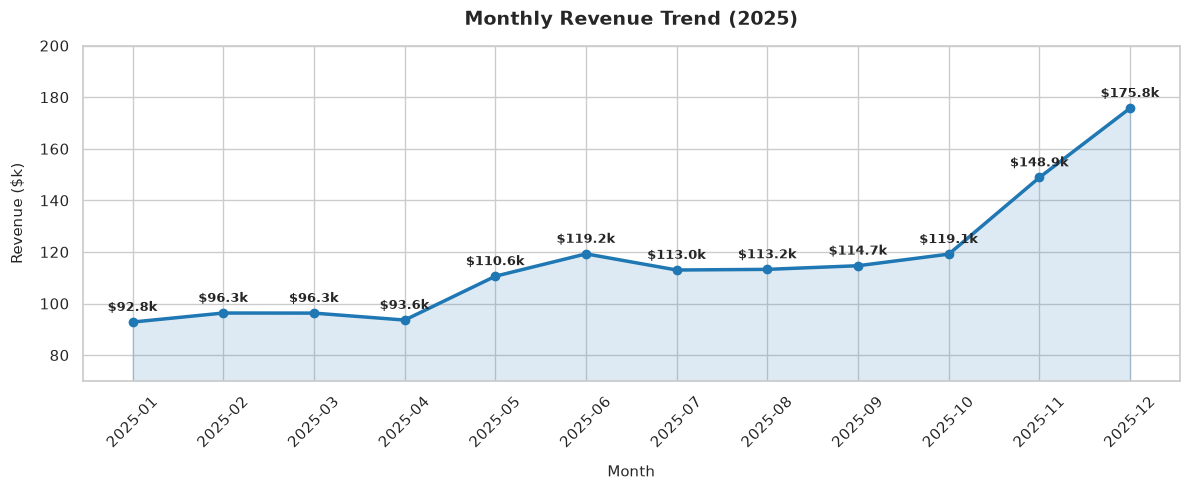

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Direct path relative to notebooks/ folder
df_orders = pd.read_csv('../data/orders_clean.csv')
df_order_items = pd.read_csv('../data/order_items_clean.csv')
df_products = pd.read_csv('../data/products_clean.csv')
df_customers = pd.read_csv('../data/customers_clean.csv')
df_sessions = pd.read_csv('../data/sessions_clean.csv')

# Set global visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})

# Prepare datasets for visualization
df_delivered = df_orders[df_orders['status'] == 'delivered'].copy()
df_delivered['order_date'] = pd.to_datetime(df_delivered['order_date'])
df_delivered['month_year'] = df_delivered['order_date'].dt.to_period('M').astype(str)


# Plot 1: Monthly Revenue Trend
monthly_rev = df_delivered.groupby('month_year')['order_amount'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_rev['month_year'], monthly_rev['order_amount'] / 1000, marker='o', linewidth=2.5, color='#1f77b4')
ax.fill_between(monthly_rev['month_year'], monthly_rev['order_amount'] / 1000, color='#1f77b4', alpha=0.15)
ax.set_title('Monthly Revenue Trend (2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11, labelpad=10)
ax.set_ylabel('Revenue ($k)', fontsize=11, labelpad=10)
plt.xticks(rotation=45)

for i, txt in enumerate(monthly_rev['order_amount'] / 1000):
    ax.annotate(f"${txt:.1f}k", (monthly_rev['month_year'][i], txt), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(70, 200)
plt.tight_layout()
plt.show()

Plot 1: **Monthly Revenue Trend (2025):** Illustrates strong positive growth momentum throughout the year, escalating from $92.8k in January to a peak of $175.8k in December due to Q4 holiday seasonality.

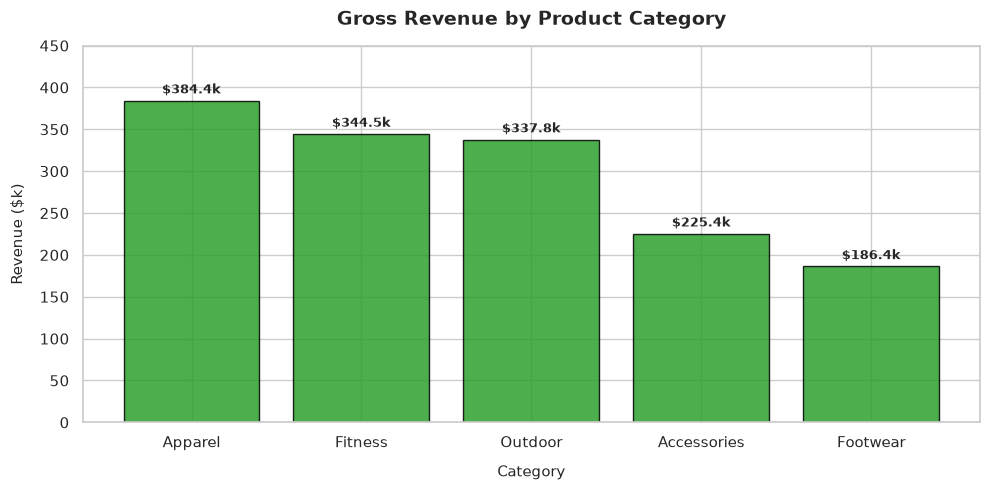

In [18]:
# Plot 2: Gross Revenue by Category
items_orders = df_order_items.merge(df_delivered[['order_id']], on='order_id')
items_prod = items_orders.merge(df_products, on='product_id')
cat_perf = items_prod.groupby('category')['line_amount'].sum().reset_index().sort_values(by='line_amount', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_perf['category'], cat_perf['line_amount'] / 1000, color='#2ca02c', alpha=0.85, edgecolor='black')
ax.set_title('Gross Revenue by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=11, labelpad=10)
ax.set_ylabel('Revenue ($k)', fontsize=11, labelpad=10)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f"${yval:.1f}k", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 450)
plt.tight_layout()
plt.show()

Plot 2: **Gross Revenue by Product Category:** Highlights **Apparel** ($384.4k), **Fitness** ($344.5k), and **Outdoor** ($337.8k) as main revenue contributors. **Footwear** ($186.4k) generates lower monetary revenue.

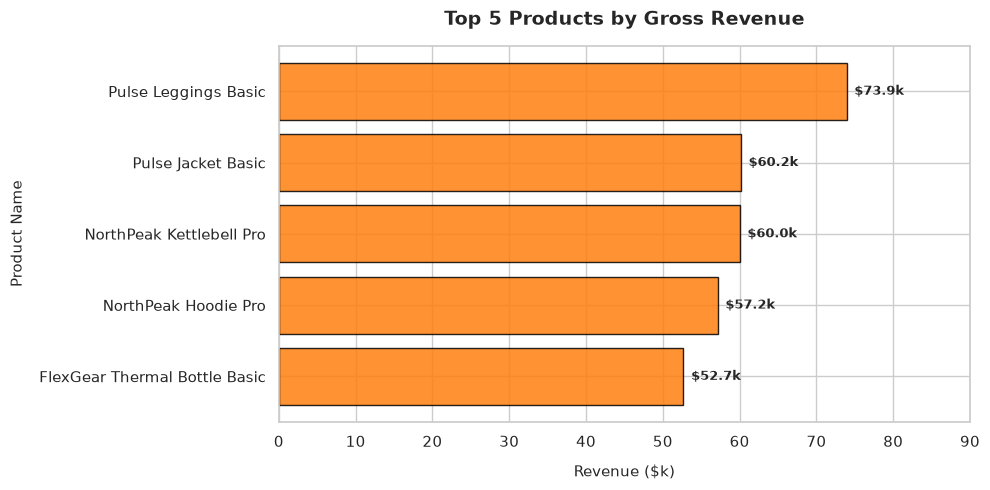

In [19]:
# Plot 3: Top 5 Products by Revenue
top_prod = items_prod.groupby('product_name')['line_amount'].sum().reset_index().sort_values(by='line_amount', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_prod['product_name'][::-1], (top_prod['line_amount'] / 1000)[::-1], color='#ff7f0e', alpha=0.85, edgecolor='black')
ax.set_title('Top 5 Products by Gross Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Revenue ($k)', fontsize=11, labelpad=10)
ax.set_ylabel('Product Name', fontsize=11, labelpad=10)

for bar in bars:
    xval = bar.get_width()
    ax.text(xval + 1, bar.get_y() + bar.get_height()/2.0, f"${xval:.1f}k", ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, 90)
plt.tight_layout()
plt.show()

Plot 3: **Top 5 Products by Revenue:** Identifies top-performing SKUs, led by *Pulse Leggings Basic* ($73.9k), *Pulse Jacket Basic* ($60.2k), and *NorthPeak Kettlebell Pro* ($60.0k).

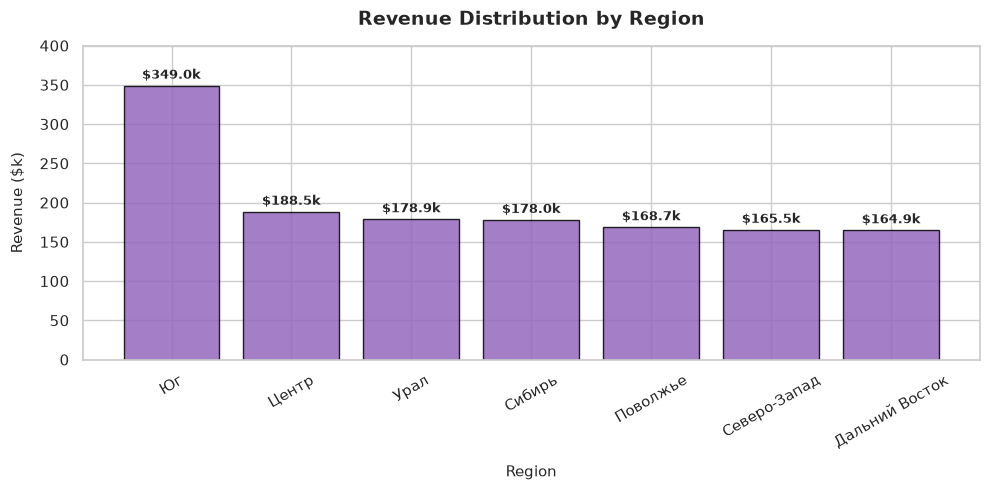

In [20]:
# Plot 4: Revenue Distribution by Region
orders_cust = df_delivered.merge(df_customers, on='customer_id')
region_perf = orders_cust.groupby('region')['order_amount'].sum().reset_index().sort_values(by='order_amount', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(region_perf['region'], region_perf['order_amount'] / 1000, color='#9467bd', alpha=0.85, edgecolor='black')
ax.set_title('Revenue Distribution by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=11, labelpad=10)
ax.set_ylabel('Revenue ($k)', fontsize=11, labelpad=10)
plt.xticks(rotation=30)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f"${yval:.1f}k", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 400)
plt.tight_layout()
plt.show()

Plot 4: **Revenue Distribution by Region:** Confirms the **Юг (South)** region as the top market segment ($349.0k), with all remaining regions performing steadily between $164.8k and $188.5k.

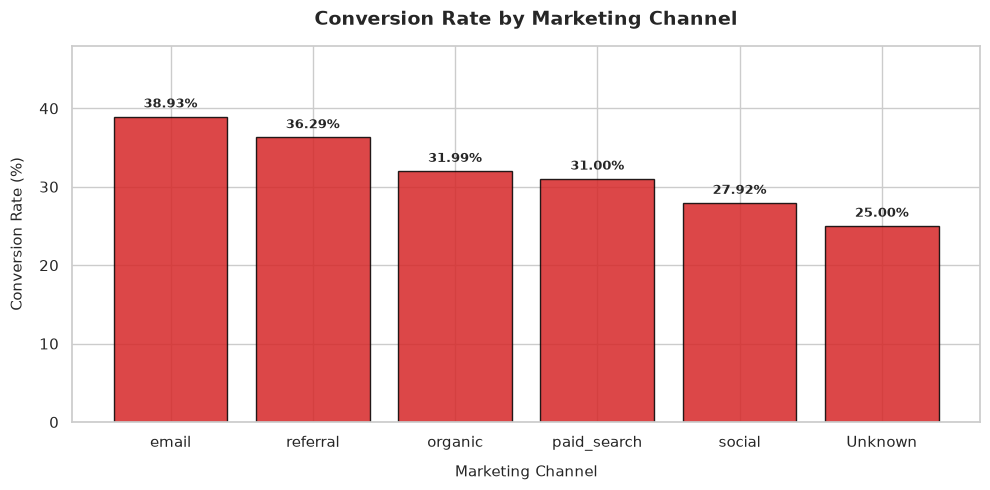

In [21]:
# Plot 5: Conversion Rate by Marketing Channel
channel_perf = df_sessions.groupby('channel').agg(
    total_sessions=('session_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()
channel_perf['cvr'] = channel_perf['conversions'] / channel_perf['total_sessions'] * 100
channel_perf = channel_perf.sort_values(by='cvr', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(channel_perf['channel'], channel_perf['cvr'], color='#d62728', alpha=0.85, edgecolor='black')
ax.set_title('Conversion Rate by Marketing Channel', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marketing Channel', fontsize=11, labelpad=10)
ax.set_ylabel('Conversion Rate (%)', fontsize=11, labelpad=10)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{yval:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 48)
plt.tight_layout()
plt.show()

Plot 5: **Conversion Rate by Marketing Channel:** Displays high channel efficiency for **Email** (**38.93%**) and **Referral** (**36.29%**), contrasting with **Social** media (**27.92%**).

C:\Users\Sveta\AppData\Local\Temp\ipykernel_23172\3860394379.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Group A (Control)', 'Group B (Treatment)'])


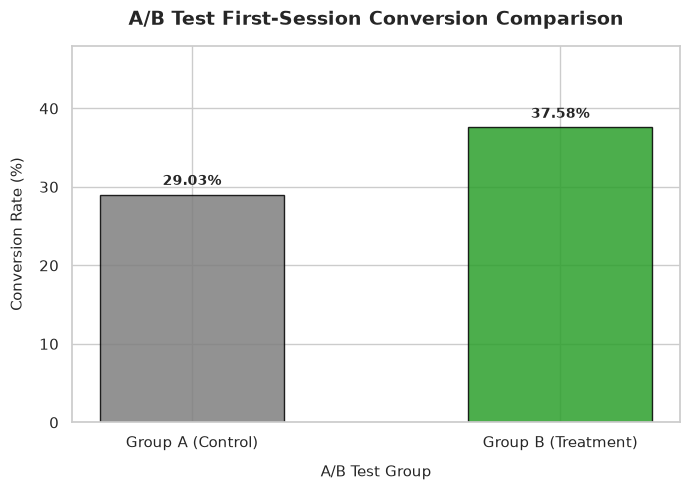

In [ ]:
# Plot 6: A/B Test First-Session Conversion Comparison
df_sessions['session_start_dt'] = pd.to_datetime(df_sessions['session_start'])
df_first_sessions = df_sessions.sort_values(by=['customer_id', 'session_start_dt']).groupby('customer_id').first().reset_index()

ab_perf = df_first_sessions.groupby('ab_group').agg(
    total_users=('customer_id', 'count'),
    conversions=('converted', 'sum'),
    cvr=('converted', 'mean')
).reset_index()
ab_perf['cvr_pct'] = ab_perf['cvr'] * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#7f7f7f', '#2ca02c']
bars = ax.bar(ab_perf['ab_group'], ab_perf['cvr_pct'], color=colors, alpha=0.85, edgecolor='black', width=0.5)
ax.set_title('A/B Test First-Session Conversion Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('A/B Test Group', fontsize=11, labelpad=10)
ax.set_ylabel('Conversion Rate (%)', fontsize=11, labelpad=10)
ax.set_xticklabels(['Group A (Control)', 'Group B (Treatment)'])

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{yval:.2f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 48)
plt.tight_layout()
plt.show()

Plot 6: **A/B Test First-Session Conversion Comparison:** Visualizes the statistically significant uplift in first-session conversion from **29.03%** (Control A) to **37.58%** (Treatment B), representing an absolute gain of **+8.55 percentage points**.

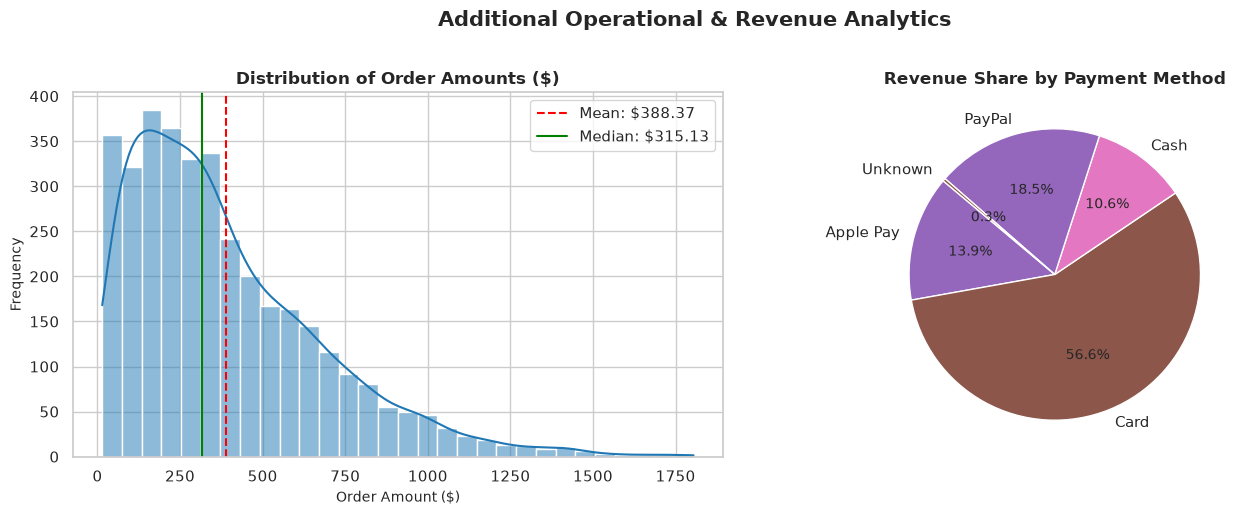

In [23]:
# Additional Exploratory Data Analysis (1x2 Grid)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Additional Operational & Revenue Analytics', fontsize=15, fontweight='bold', y=1.02)

# Subplot 1: Distribution of Order Amount
sns.histplot(df_delivered['order_amount'], kde=True, ax=axes[0], color='#1f77b4', bins=30)
axes[0].set_title('Distribution of Order Amounts ($)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Order Amount ($)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)

mean_val = df_delivered['order_amount'].mean()
median_val = df_delivered['order_amount'].median()

axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${mean_val:.2f}')
axes[0].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: ${median_val:.2f}')
axes[0].legend()

# Subplot 2: Revenue Breakdown by Payment Method
payment_rev = df_delivered.groupby('payment_method')['order_amount'].sum().reset_index()
axes[1].pie(payment_rev['order_amount'], labels=payment_rev['payment_method'], autopct='%1.1f%%', startangle=140, colors=['#9467bd', '#8c564b', '#e377c2'])
axes[1].set_title('Revenue Share by Payment Method', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Additional Exploratory Charts (1x2 Grid Summary)
* **Order Amount Distribution:** Order amounts follow a right-skewed distribution with a median of **$315.13** and a mean of **$388.37**, where higher-value orders stretch the distribution tail beyond $1,500.
* **Payment Method Breakdown:** **Card** payments clearly dominate total revenue at **56.6%**, followed by **PayPal** (**18.5%**), **Apple Pay** (**13.9%**), and **Cash** (**10.6%**).